In [1]:
import sympy as sp
import networkx as nx
import numpy as np
import tqdm

import matplotlib.pyplot as plt


from linearframework.linear_framework_graph import LinearFrameworkGraph
import linearframework.ca_recurrence as ca
import linearframework.linear_framework_results as lfr
import linearframework.generalized_aldous_schepp as gas

This notebook is for running numerical experiments on the generalized aldous-shepp result.

We work with 2 graphs and test whether the graph is bounded below by the longest embedded erlang on the graph, from the source to the target, or the erlang with the same number of states.

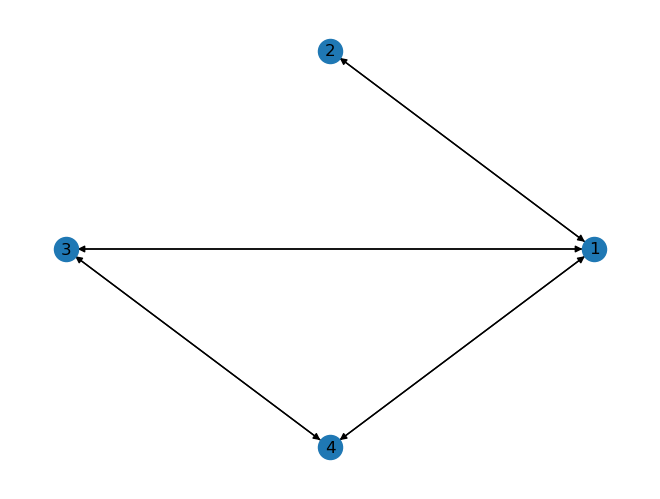

In [3]:
edges_1 = [
    ('1', '2'), ('2', '1'),
    ('1', '3'), ('3', '1'),
    ('1', '4'), ('4', '1'),
    ('3', '4'), ('4', '3')
]

g_1 = LinearFrameworkGraph(edges_1)

nx.draw_circular(g_1.nx_graph, with_labels=True)

In [6]:
s2g1 = gas.generalized_randomness_parameter(g_1, '1', '3', 2)

s2g1

(2*l_1*l_2*l_5*l_6 + 2*l_2**2*l_5*l_6 + 2*l_2*l_5*(l_1*l_6 + l_1*l_8) + 2*l_2*l_5*(l_2*l_3 + l_2*l_5) + 2*l_2*l_5*(l_2*l_6 + l_2*l_8) + 4*(l_1*l_6 + l_1*l_8)*(l_2*l_6 + l_2*l_8) + 2*(l_1*l_6 + l_1*l_8)*(l_1*l_6 + l_1*l_8 + l_3*l_6 + l_3*l_8 + l_5*l_8) + 2*(l_2*l_6 + l_2*l_8)**2)/(l_1*l_6 + l_1*l_8 + l_2*l_5 + l_2*l_6 + l_2*l_8)**2

In [13]:
def make_powered_edge_to_weight(powered_edges):

    powered_edge_to_weight = {}

    for edge in g_1.edges:
        if edge in powered_edges:
            powered_edge_to_weight[edge] = 100
        else:
            powered_edge_to_weight[edge] = 0.001

    return powered_edge_to_weight

powered_whole_edges = [('2', '1'), ('1', '4'), ('4', '3')]

powered_whole_edge_to_weight = make_powered_edge_to_weight(powered_whole_edges)

powered_whole_edge_to_weight

{('1', '2'): 0.001,
 ('2', '1'): 100,
 ('1', '3'): 0.001,
 ('3', '1'): 0.001,
 ('1', '4'): 100,
 ('4', '1'): 0.001,
 ('3', '4'): 0.001,
 ('4', '3'): 100}

In [14]:
powered_path_edges = [ ('1', '4'), ('4', '3')]

powered_path_edge_to_weight = make_powered_edge_to_weight(powered_path_edges)

powered_path_edge_to_weight

{('1', '2'): 0.001,
 ('2', '1'): 0.001,
 ('1', '3'): 0.001,
 ('3', '1'): 0.001,
 ('1', '4'): 100,
 ('4', '1'): 0.001,
 ('3', '4'): 0.001,
 ('4', '3'): 100}

In [15]:
powered_uniform_edge_to_weight = make_powered_edge_to_weight(g_1.edges)

powered_uniform_edge_to_weight

{('1', '2'): 100,
 ('2', '1'): 100,
 ('1', '3'): 100,
 ('3', '1'): 100,
 ('1', '4'): 100,
 ('4', '1'): 100,
 ('3', '4'): 100,
 ('4', '3'): 100}

In [17]:
powered_whole_sym_to_weight = g_1.make_sym_to_weight(powered_whole_edge_to_weight)

whole_embed_s2g1 = s2g1.subs(powered_whole_sym_to_weight)

whole_embed_s2g1

1.50001499990000

In [29]:
uniform_sym_to_weight = g_1.make_sym_to_weight(powered_uniform_edge_to_weight)

path_embed_s2g1 = s2g1.subs(uniform_sym_to_weight)

path_embed_s2g1

12/5

In [31]:
gas.guzman_alca_equation(3, 2)

1.5